# Análisis y Visualización de Clústeres HDBSCAN

## 1. Configuración y Carga de Datos

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

# Asegúrate de que las rutas sean correctas para tu entorno
BASE_OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "output")
FINAL_CLUSTER_RESULTS_DIR = os.path.join(BASE_OUTPUT_DIR, "Trial_2")

# Archivos de resultados
MODULE_ANALYSIS_SUMMARY_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_module_analysis_summary.csv")
PROTEINS_WITH_GO_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_proteins_with_representative_go.csv")
HDBSCAN_CLUSTER_LABELS_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR,"final_hdbscan_clusters", "hdbscan_cluster_labels_mcs20_ms20_cse0.00_alpha2.0.csv")

# También necesitarás el archivo GO.csv para todos los términos GO
GO_TERMS_PATH = os.path.join(os.path.dirname(os.getcwd()),"input", "GO.csv")
GO_METADATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "input", "metadata_GO.csv")

# Cargar los DataFrames
try:
    df_module_summary = pd.read_csv(MODULE_ANALYSIS_SUMMARY_PATH)
    df_proteins_go = pd.read_csv(PROTEINS_WITH_GO_PATH)
    df_go_terms_all = pd.read_csv(GO_TERMS_PATH, sep='\t') # Asume que GO.csv usa tab como separador
    df_hdbscan_labels = pd.read_csv(HDBSCAN_CLUSTER_LABELS_PATH)
    df_go_metadata = pd.read_csv(GO_METADATA_PATH, sep=',')
    
    print("Archivos cargados exitosamente:")
    print(f" - Resumen de módulos: {len(df_module_summary)} filas")
    print(f" - Proteínas con GO representativo: {len(df_proteins_go)} filas")
    print(f" - Todos los GO terms (para mapeo): {len(df_go_terms_all)} filas")
    print(f" - Etiquetas de clúster HDBSCAN: {len(df_hdbscan_labels)} filas")
    print(f" - Metadata GO: {len(df_go_metadata)} filas")

     # Mapear las proteínas a sus GO terms completos (no solo el representativo del módulo)
    protein_to_all_go_terms = defaultdict(set)
    for _, row in df_go_terms_all.iterrows():
        protein_to_all_go_terms[row['proteina']].add(row['GO_term'])

    # Mapear proteínas a módulos usando df_hdbscan_labels
    protein_module_map = df_hdbscan_labels.set_index('protein_id')['cluster_label'].to_dict()

    # Crear un mapa de módulo a lista de proteínas
    module_to_proteins = defaultdict(list)
    for protein, module_id in protein_module_map.items():
        if module_id != -1: # Excluir ruido para la mayoría de los análisis de clústeres
            module_to_proteins[module_id].append(protein)
    
    # Obtener IDs de clúster válidos y ordenarlos (para el heatmap Jaccard y de términos específicos)
    valid_cluster_ids = sorted(list(module_to_proteins.keys()))
    print(f"Clústeres válidos encontrados: {valid_cluster_ids}")

    # Crear un mapeo de GO_term a Term_Name_Clean para acceso rápido
    go_term_to_name = df_go_metadata.set_index('GO_term')['Term_Name_Clean'].to_dict() # <--- AÑADIDO

except FileNotFoundError as e:
    print(f"Error: Asegúrate de que todos los archivos estén en las rutas correctas. {e}")
    # Puedes salir o manejar el error de otra forma
except Exception as e:
    print(f"Ocurrió un error al cargar los datos: {e}")

Archivos cargados exitosamente:
 - Resumen de módulos: 15 filas
 - Proteínas con GO representativo: 1083 filas
 - Todos los GO terms (para mapeo): 181312 filas
 - Etiquetas de clúster HDBSCAN: 5390 filas
 - Metadata GO: 6928 filas
Clústeres válidos encontrados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


## 2. Heatmap de Similitud de Clústeres (Basado en GO Terms)

Para crear un heatmap que muestre cuán "parecidos" son los clústeres, podemos calcular una métrica de similitud entre ellos.
Una forma robusta es calcular la **similitud Jaccard** o la **similitud de superposición** de los conjuntos de términos GO asociados a las proteínas de cada clúster.

**Estrategia:**
1. Para cada clúster, recopilar *todos* los términos GO de las proteínas que lo componen.
2. Calcular la similitud (e.g., Jaccard Index) entre el conjunto de GO terms de cada par de clústeres.
   * **Jaccard Index (A, B) = |A ∩ B| / |A ∪ B|**
   * Donde A y B son los conjuntos de GO terms de dos clústeres.
 3. Visualizar la matriz de similitud como un heatmap.

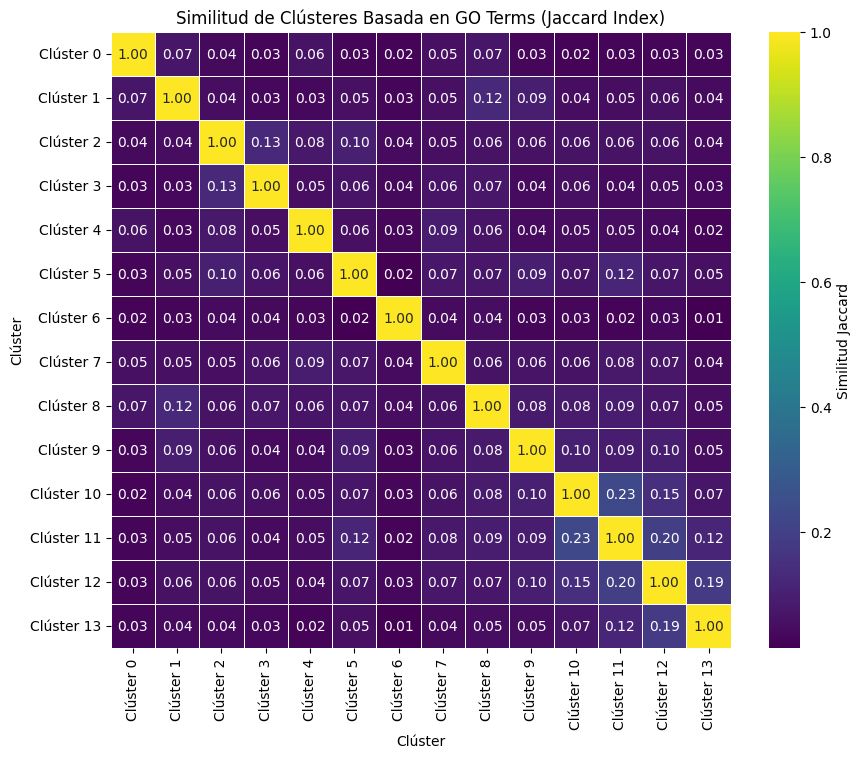

In [47]:

# Paso 1: Recopilar todos los GO terms por clúster (excluyendo ruido)
cluster_go_sets = {}
for module_id, proteins_in_module in module_to_proteins.items():
    current_go_set = set()
    for protein_id in proteins_in_module:
        current_go_set.update(protein_to_all_go_terms[protein_id])
    cluster_go_sets[module_id] = current_go_set

# Obtener IDs de clúster válidos y ordenarlos
valid_cluster_ids = sorted(list(cluster_go_sets.keys()))
num_clusters = len(valid_cluster_ids)

# Paso 2: Calcular la matriz de similitud Jaccard
jaccard_similarity_matrix = np.zeros((num_clusters, num_clusters))

for i, cluster_a_id in enumerate(valid_cluster_ids):
    for j, cluster_b_id in enumerate(valid_cluster_ids):
        set_a = cluster_go_sets[cluster_a_id]
        set_b = cluster_go_sets[cluster_b_id]

        if not set_a or not set_b: # Evitar división por cero si un clúster no tiene GO terms
            jaccard_similarity_matrix[i, j] = 0.0
            continue
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        
        if union == 0:
            jaccard_similarity_matrix[i, j] = 0.0
        else:
            jaccard_similarity_matrix[i, j] = intersection / union

# Crear un DataFrame para el heatmap
df_jaccard = pd.DataFrame(jaccard_similarity_matrix, 
                          index=[f'Clúster {cid}' for cid in valid_cluster_ids], 
                          columns=[f'Clúster {cid}' for cid in valid_cluster_ids])

# Paso 3: Visualizar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_jaccard, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Similitud Jaccard'})
plt.title('Similitud de Clústeres Basada en GO Terms (Jaccard Index)')
plt.xlabel('Clúster')
plt.ylabel('Clúster')
plt.show()

**Interpretación del Heatmap de Similitud GO:**

* **Diagonal:** Siempre será 1.00, ya que un clúster es idéntico a sí mismo.
* **Valores altos (cercanos a 1):** Indican que los dos clústeres comparten una alta proporción de sus términos GO asociados, sugiriendo funciones biológicas similares o relacionadas.
* **Valores bajos (cercanos a 0):** Indican que los clústeres tienen pocos o ningún término GO en común, sugiriendo funciones biológicas muy distintas.
Esto te ayudará a identificar si algunos de tus 7 clústeres, aunque distintos en el espacio de embeddings, tienen solapamiento funcional.

### 3.1. Distribución de Target_Group por Clúster (Gráfico de Barras Apiladas)

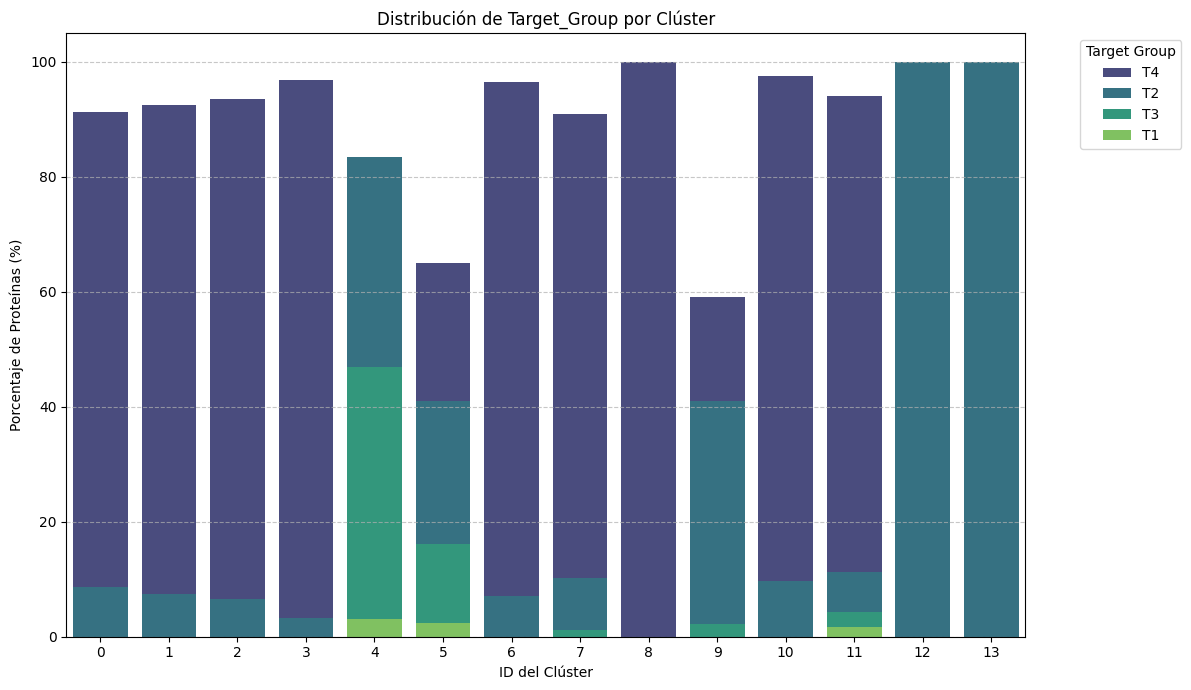

In [48]:
# Esto te permitirá comparar visualmente las proporciones de T1, T2, T3, T4 en cada clúster.

# Preparar los datos para el gráfico de barras apiladas de Target_Group
# Necesitamos parsear la columna 'target_group_distribution'
parsed_target_groups = []
for _, row in df_module_summary.iterrows():
    module_id = row['module_id']
    if module_id == -1: # Puedes incluir el ruido si quieres, o excluirlo
        continue
    
    # Evaluar la cadena a un diccionario
    tg_dist_str = row['target_group_distribution']
    # Eliminar las comillas dobles si las hay antes de evaluar
    tg_dist_str = tg_dist_str.replace("'", "\"")
    try:
        tg_dict = eval(tg_dist_str) # Cuidado con eval, solo si confías en el origen de los datos
    except:
        print(f"Error al parsear target_group_distribution para módulo {module_id}: {tg_dist_str}")
        continue

    total_percentage = 0.0
    for tg, percentage_str in tg_dict.items():
        percentage = float(percentage_str.replace('%', ''))
        parsed_target_groups.append({'module_id': module_id, 'Target_Group': tg, 'Percentage': percentage})
        total_percentage += percentage
    
    # Handle cases where total is not 100% due to floating point or missing groups
    # You might want to normalize if sum is not 100
    # if abs(total_percentage - 100.0) > 0.01 and total_percentage > 0:
    #     print(f"Warning: Module {module_id} target group percentages sum to {total_percentage:.2f}%")

df_tg_distribution = pd.DataFrame(parsed_target_groups)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_tg_distribution, x='module_id', y='Percentage', hue='Target_Group', palette='viridis', dodge=False)
plt.title('Distribución de Target_Group por Clúster')
plt.xlabel('ID del Clúster')
plt.ylabel('Porcentaje de Proteínas (%)')
plt.legend(title='Target Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.2. Distribución de Proteínas DEG por Clúster (Gráfico de Barras Apiladas)


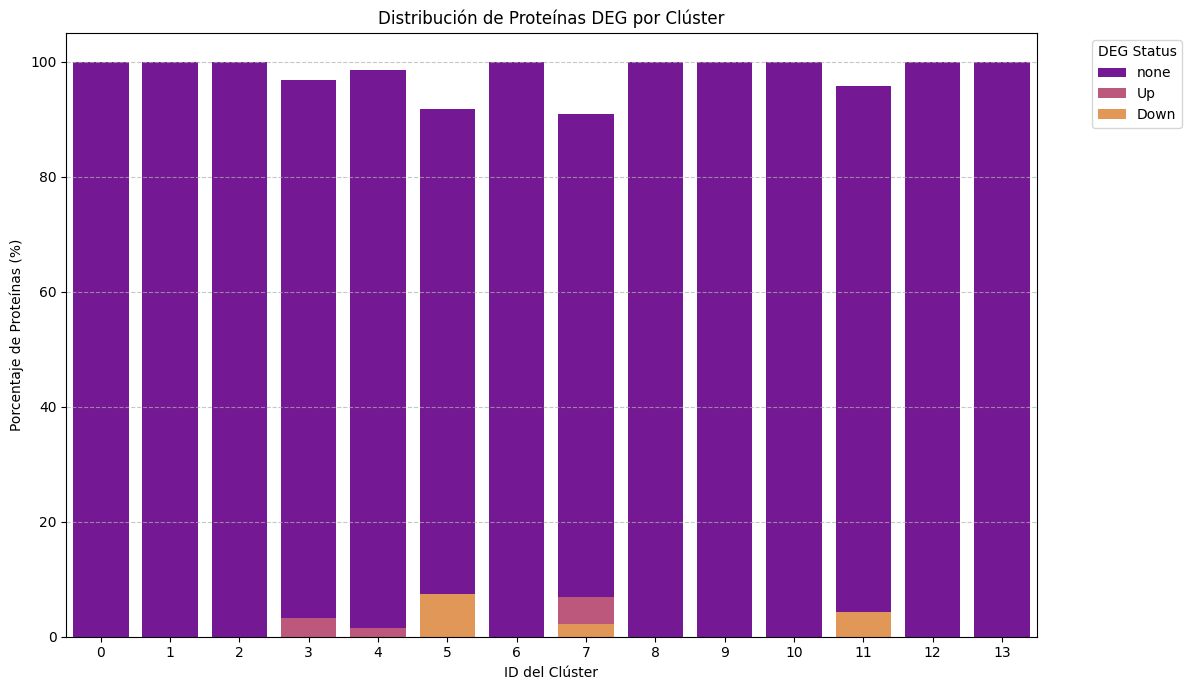

In [49]:
# Similar al anterior, pero para las proteínas diferencialmente expresadas.

# Preparar los datos para el gráfico de barras apiladas de DEG
# Necesitamos parsear la columna 'deg_distribution'
parsed_degs = []
for _, row in df_module_summary.iterrows():
    module_id = row['module_id']
    if module_id == -1: # Puedes incluir el ruido si quieres, o excluirlo
        continue

    deg_dist_str = row['deg_distribution']
    deg_dist_str = deg_dist_str.replace("'", "\"")
    try:
        deg_dict = eval(deg_dist_str)
    except:
        print(f"Error al parsear deg_distribution para módulo {module_id}: {deg_dist_str}")
        continue
    
    total_percentage = 0.0
    for status, percentage_str in deg_dict.items():
        percentage = float(percentage_str.replace('%', ''))
        parsed_degs.append({'module_id': module_id, 'DEG_Status': status, 'Percentage': percentage})
        total_percentage += percentage

df_deg_distribution = pd.DataFrame(parsed_degs)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_deg_distribution, x='module_id', y='Percentage', hue='DEG_Status', palette='plasma', dodge=False)
plt.title('Distribución de Proteínas DEG por Clúster')
plt.xlabel('ID del Clúster')
plt.ylabel('Porcentaje de Proteínas (%)')
plt.legend(title='DEG Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 ### 3.3. Tamaño de los Clústeres y su GO Representativo (Tabla Resumen)

In [50]:
# Una tabla simple para ver rápidamente el tamaño y la función principal de cada clúster.

# Filtrar solo los clústeres válidos (excluir ruido)
df_summary_display = df_module_summary[df_module_summary['module_id'] != -1].copy()

# Opcional: Simplificar la columna 'proteins' si es muy larga para la vista
df_summary_display['proteins_sample'] = df_summary_display['proteins'].apply(lambda x: ', '.join(x.split(', ')[:5]) + '...' if len(x.split(', ')) > 5 else x)

# Seleccionar y reordenar columnas para una mejor visualización
summary_cols = ['module_id', 'module_size', 'representative_go', 'representative_go_p_value', 
                'deg_distribution', 'target_group_distribution', 'proteins_sample']

display(df_summary_display[summary_cols])


,module_id,module_size,representative_go,representative_go_p_value,deg_distribution,target_group_distribution,proteins_sample
1,0,23,GO:0043202 (Lysosomal Lumen),1.639042e-25,{'none': '100.00%'},"{'T4': '91.30%', 'T2': '8.70%'}","MAN2B1, GLB1, ASAH1, NAGLU, IDUA..."
2,1,40,GO:1903027 (Regulation Of Opsonization),2.287545e-23,{'none': '100.00%'},"{'T4': '92.50%', 'T2': '7.50%'}","SERPING1, CPX-6211, CPX-6215, APCS, SERPINF2..."
3,2,61,GO:0007601 (Visual Perception),1.937404e-18,{'none': '100.00%'},"{'T4': '93.44%', 'T2': '6.56%'}","ROM1, RD3, KCNV2, CRX, ABCA4..."
4,3,31,GO:0007605 (Sensory Perception Of Sound),1.356550e-24,"{'none': '96.77%', 'Up': '3.23%'}","{'T4': '96.77%', 'T2': '3.23%'}","ILDR1, CLIC5, PCDH15, GRXCR2, GRXCR1..."
5,4,66,GO:0019585 (Glucuronate Metabolic Process),2.040040e-28,"{'none': '98.48%', 'Up': '1.52%'}","{'T4': '16.67%', 'T2': '83.33%', 'T3': '46.97%...","AKR1D1, CYP2C9, CYP2C19, CYP1A2, CYP2A6..."
6,5,366,GO:0098916 (Anterograde Trans-Synaptic Signaling),9.480695e-124,"{'none': '91.80%', 'Down': '7.38%', 'Up': '0.8...","{'T2': '40.98%', 'T3': '16.12%', 'T4': '65.03%...","DRD4, GNB3, GNB4, SLC6A4, GNB5..."
7,6,28,GO:0004812 (aminoacyl-tRNA Ligase Activity),1.072460e-41,{'none': '100.00%'},"{'T4': '96.43%', 'T2': '7.14%'}","TSFM, EARS2, SARS1, AARS1, NARS1..."
8,7,88,GO:0005759 (Mitochondrial Matrix),1.862956e-37,"{'none': '90.91%', 'Up': '6.82%', 'Down': '2.2...","{'T4': '90.91%', 'T2': '10.23%', 'T3': '1.14%'}","GALM, CPX-6236, PKLR, GBE1, PGD..."
9,8,53,GO:0062023 (Collagen-Containing Extracellular ...,1.789903e-54,{'none': '100.00%'},{'T4': '100.00%'},"CPX-466, BMP1, CPX-1772, CPX-1776, CPX-1778..."
10,9,44,GO:0038196 (Type III Interferon-Mediated Signa...,5.148172e-46,{'none': '100.00%'},"{'T4': '59.09%', 'T2': '40.91%', 'T3': '2.27%'}","IRF1, TLR9, CD79A, TLR3, ICOS..."


### 3.4. (Avanzado) Similitud de GO a nivel de términos específicos

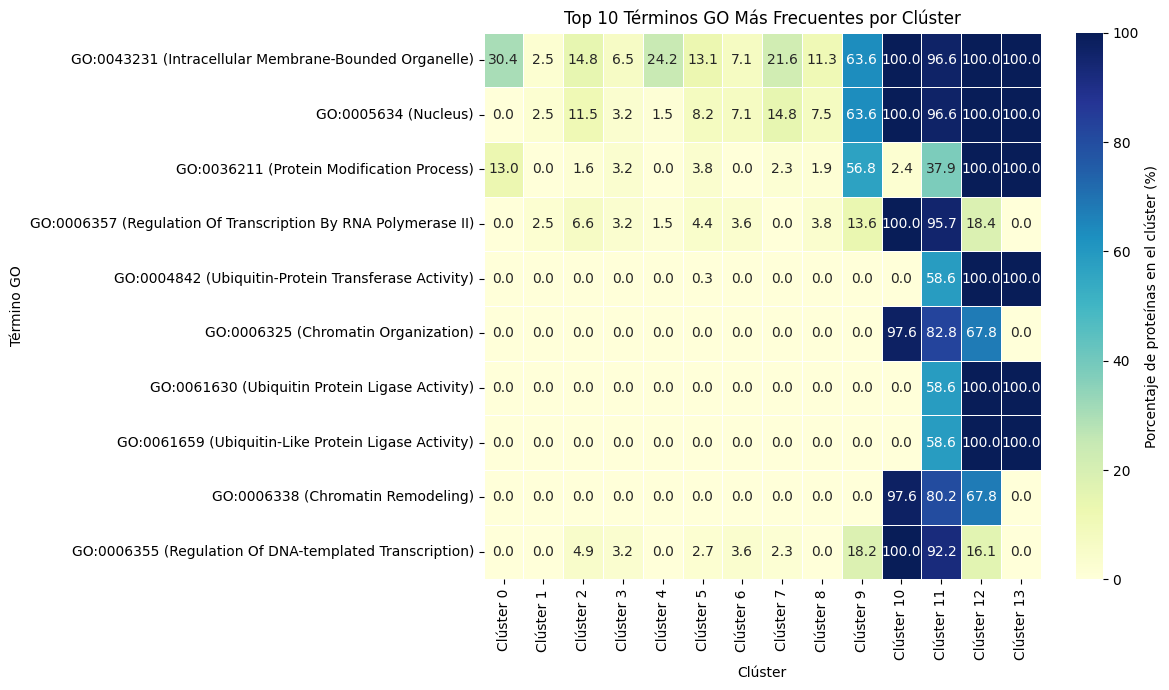

In [51]:

# Para una comprensión más profunda de la superposición funcional, podemos identificar los top N términos GO más 
# frecuentes en cada clúster (excluyendo el ruido) y luego visualizar sus frecuencias a través de todos los clústeres en un heatmap.
# Esto nos permite ver qué funciones son prominentes en cada grupo y cuáles son compartidas.


from collections import Counter

# Definir el número de top GO terms a considerar por clúster
TOP_N_GO_TERMS = 10 

# Recopilar todos los GO terms (con sus nombres) para cada clúster
cluster_go_term_counts = {}
for module_id in valid_cluster_ids: # valid_cluster_ids ya excluye el ruido
    proteins_in_module = module_to_proteins.get(module_id, [])
    
    all_go_terms_for_module = []
    for protein_id in proteins_in_module:
        all_go_terms_for_module.extend(list(protein_to_all_go_terms[protein_id]))
    
    go_counts = Counter(all_go_terms_for_module)
    cluster_go_term_counts[module_id] = go_counts

# Identificar los TOP N GO terms globales (los más frecuentes en el conjunto de todos los clústeres)
global_top_go_terms = Counter()
for module_id, counts in cluster_go_term_counts.items():
    global_top_go_terms.update(counts)

# Seleccionar los TOP N términos más frecuentes en el universo de clústeres no ruidosos
common_go_terms_for_heatmap = [go_term for go_term, _ in global_top_go_terms.most_common(TOP_N_GO_TERMS)]

# Preparar la matriz de frecuencia para el heatmap
# Filas: GO Terms, Columnas: Clústeres
heatmap_data = pd.DataFrame(index=[f"{term} ({go_term_to_name.get(term, 'N/A')})" # <--- CAMBIO AQUÍ
                                   for term in common_go_terms_for_heatmap],
                            columns=[f'Clúster {cid}' for cid in valid_cluster_ids])

for go_term_full_name in heatmap_data.index:
    # Extraer el GO_term puro si incluye el nombre limpio
    go_term_id = go_term_full_name.split(' ')[0] 
    
    for cluster_col in heatmap_data.columns:
        cluster_id = int(cluster_col.split(' ')[1])
        
        # Obtener el número total de proteínas en el módulo para normalizar
        module_size = len(module_to_proteins.get(cluster_id, []))
        
        if module_size > 0:
            # Frecuencia del GO term en este módulo
            count = cluster_go_term_counts[cluster_id].get(go_term_id, 0)
            heatmap_data.loc[go_term_full_name, cluster_col] = (count / module_size) * 100 # Porcentaje
        else:
            heatmap_data.loc[go_term_full_name, cluster_col] = 0

heatmap_data = heatmap_data.astype(float) # Asegurar que los datos son numéricos

# Paso 3: Visualizar el heatmap
plt.figure(figsize=(12, TOP_N_GO_TERMS * 0.7)) # Ajustar tamaño vertical según N
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5, cbar_kws={'label': 'Porcentaje de proteínas en el clúster (%)'})
plt.title(f'Top {TOP_N_GO_TERMS} Términos GO Más Frecuentes por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Término GO')
plt.tight_layout()
plt.show()

**Interpretación de este Heatmap de Frecuencia de GO:**

* **Filas:** Representan los GO terms más comunes en tus clústeres.
* **Columnas:** Representan cada uno de tus clústeres.
* **Celdas:** Muestran el **porcentaje de proteínas dentro de ese clúster** que están anotadas con ese término GO específico.
* **Valores altos (colores oscuros):** Indican que ese término GO es muy prevalente en ese clúster particular.
* **Patrones:** Observa si hay términos GO que son muy altos en uno o dos clústeres pero bajos en otros, lo que indica especialización funcional. También busca términos que sean moderadamente altos en muchos clústeres, sugiriendo funciones más generales o compartidas.


### 3.5. (Si tienes el UMAP de antes) Volver a visualizar el UMAP con anotaciones


c:\Users\Macarena Madrid\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


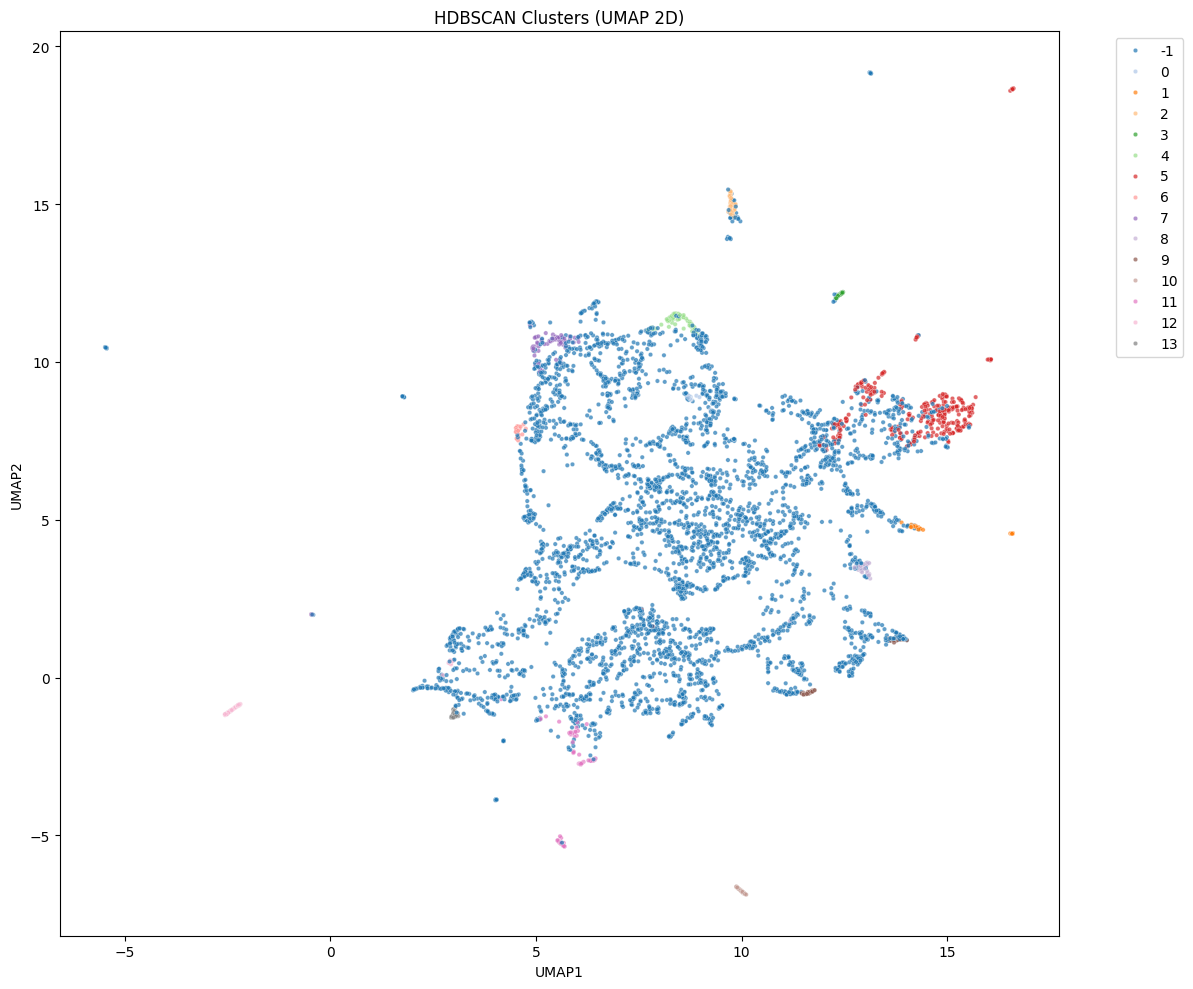

In [52]:
from umap import UMAP # Asegúrate de importar UMAP

df_embeddings = pd.read_csv(os.path.join(BASE_OUTPUT_DIR, "Trial_2", "embeddings_normalizados.csv"))
X = df_embeddings.iloc[:, 1:].values
protein_ids = df_embeddings.iloc[:, 0].tolist()

reducer = UMAP(n_components=2, random_state=42, metric='cosine')
X_reduced = reducer.fit_transform(X)

df_plot = pd.DataFrame(X_reduced, columns=['UMAP1', 'UMAP2'])
df_plot['protein_id'] = protein_ids
df_plot = df_plot.merge(df_hdbscan_labels, on='protein_id') # Unir con las etiquetas de clúster

plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_plot, x='UMAP1', y='UMAP2', hue='cluster_label', 
                 palette='tab10' if len(df_plot['cluster_label'].unique()) <= 10 else 'tab20', 
                 alpha=0.7, s=10)
plt.title('HDBSCAN Clusters (UMAP 2D)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Identificación y Visualización de Proteínas Moduladoras (Hubs)


In [53]:
# Las proteínas moduladoras, a menudo llamadas "hubs" en redes biológicas, son aquellas que tienen un alto grado de conectividad o centralidad,
# sugiriendo un papel importante en la coordinación y regulación dentro de sus respectivos módulos.
#
# Para este análisis, usaremos el archivo interacciones proteína-proteína (`edges.csv`) que define la conectividad.

import networkx as nx # Librería para trabajar con grafos

# --- Configuración y Carga de la Red PPI ---
PPI_EDGES_PATH = os.path.join(os.path.dirname(os.getcwd()),"input", "Edge.csv") 

# Cargar el DataFrame de interacciones
try:
    df_edges = pd.read_csv(PPI_EDGES_PATH, sep='\t') 
    print(f"Archivo de interacciones (edges) cargado: {len(df_edges)} interacciones.")
    print("Primeras 5 filas del DataFrame de interacciones:")
    print(df_edges.head())
    
    # Crear un objeto grafo de NetworkX
    G = nx.from_pandas_edgelist(df_edges, 'proteina1', 'proteina2')
    print(f"Grafo de red creado con {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")


except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo de interacciones en {PPI_EDGES_PATH}. {e}")
    print("Por favor, ajusta la ruta o asegúrate de que el archivo exista para este análisis.")
    G = None # Establecer G a None para evitar errores posteriores
except Exception as e:
    print(f"Ocurrió un error al cargar o construir el grafo: {e}")
    G = None

Archivo de interacciones (edges) cargado: 430206 interacciones.
Primeras 5 filas del DataFrame de interacciones:
  proteina1 proteina2  interaction_score
0      DRD4      HTR7              0.441
1      DRD4       LEP              0.457
2      DRD4  CPX-2175              0.509
3      DRD4   CPX-271              0.509
4      DRD4   CPX-272              0.509
Grafo de red creado con 5390 nodos y 430206 aristas.


In [54]:
# --- Calcular Métricas de Centralidad ---
if G:
    print("Calculando métricas de centralidad...")
    # Grado: Número de conexiones de un nodo
    node_degrees = dict(G.degree())
    
    # Betweenness Centrality: Medida de qué tan a menudo un nodo se encuentra en los caminos más cortos entre otros pares de nodos.
    # Es computacionalmente más costosa para grafos muy grandes. Considera un subconjunto o solo el grado si el grafo es enorme.
    # Si tu grafo es muy grande (>10,000 nodos), esta línea puede tardar mucho o consumir mucha RAM.
    # Puedes comentar las líneas de betweenness y eigenvector si hay problemas de rendimiento.
    node_betweenness = nx.betweenness_centrality(G) 
    
    # Eigenvector Centrality: Mide la influencia de un nodo en una red.
    # Los nodos con alta centralidad de eigenvector están conectados a otros nodos de alta centralidad.
    node_eigenvector = nx.eigenvector_centrality(G) 

    # Combinar métricas en un DataFrame para facilitar el análisis
    df_centrality = pd.DataFrame.from_dict(node_degrees, orient='index', columns=['degree'])
    df_centrality['betweenness_centrality'] = pd.Series(node_betweenness)
    df_centrality['eigenvector_centrality'] = pd.Series(node_eigenvector)
    df_centrality.index.name = 'protein_id'
    print("Métricas de centralidad calculadas.")
    
    # Unir las métricas de centralidad con las etiquetas de clúster
    df_centrality = df_centrality.merge(df_hdbscan_labels, on='protein_id', how='left')
    
    # Asegurarse de que las proteínas sin clúster (ruido) también se incluyan o se filtren según el análisis
    # Para hubs, nos interesan principalmente los clústeres no ruidosos.
    df_centrality_filtered = df_centrality[df_centrality['cluster_label'] != -1].copy()


Calculando métricas de centralidad...
Métricas de centralidad calculadas.


### 4.1. Top N Proteínas Hub por Clúster

In [55]:
# Una tabla que muestre las proteínas con mayor grado (o las métricas de centralidad que elijas) dentro de cada clúster.

N_HUBS = 5 # Número de hubs a mostrar por clúster
print(f"\n--- Top {N_HUBS} Proteínas Hub por Clúster (Basado en Grado) ---")
hub_proteins_by_cluster = {}
for cluster_id in valid_cluster_ids:
        cluster_df = df_centrality_filtered[df_centrality_filtered['cluster_label'] == cluster_id]
        if not cluster_df.empty:
            # Ordenar por 'degree' (grado) de forma descendente
            top_hubs = cluster_df.sort_values(by='degree', ascending=False).head(N_HUBS)
            hub_proteins_by_cluster[cluster_id] = top_hubs[['protein_id', 'degree']].to_dict('records')
            
            print(f"\n--- Clúster {cluster_id} (GO Representativo: {df_module_summary[df_module_summary['module_id'] == cluster_id]['representative_go'].iloc[0]}) ---")
            for i, row in top_hubs.iterrows():
                print(f"  - {row['protein_id']} (Grado: {int(row['degree'])})")
        else:
            print(f"\n--- Clúster {cluster_id}: No hay proteínas en este clúster (o solo ruido). ---")

    # Si quieres guardar esta información en un CSV
pd.DataFrame([(cid, p['protein_id'], p['degree']) for cid, hubs in hub_proteins_by_cluster.items() for p in hubs],
             columns=['Cluster_ID', 'Protein_ID', 'Degree']).to_csv("top_hubs_by_cluster.csv", index=False)



--- Top 5 Proteínas Hub por Clúster (Basado en Grado) ---

--- Clúster 0 (GO Representativo: GO:0043202 (Lysosomal Lumen)) ---
  - GLB1 (Grado: 60)
  - ASAH1 (Grado: 41)
  - GALNS (Grado: 39)
  - FUCA1 (Grado: 36)
  - MAN2B1 (Grado: 33)

--- Clúster 1 (GO Representativo: GO:1903027 (Regulation Of Opsonization)) ---
  - CPX-6223 (Grado: 131)
  - CPX-5675 (Grado: 130)
  - SERPINC1 (Grado: 117)
  - C4B (Grado: 111)
  - CD59 (Grado: 99)

--- Clúster 2 (GO Representativo: GO:0007601 (Visual Perception)) ---
  - RPE65 (Grado: 127)
  - PDE6B (Grado: 123)
  - ENTPD3 (Grado: 105)
  - PDE6A (Grado: 100)
  - GUCY2D (Grado: 99)

--- Clúster 3 (GO Representativo: GO:0007605 (Sensory Perception Of Sound)) ---
  - PJVK (Grado: 60)
  - GRXCR1 (Grado: 59)
  - TPRN (Grado: 57)
  - ESPN (Grado: 55)
  - TRIOBP (Grado: 54)

--- Clúster 4 (GO Representativo: GO:0019585 (Glucuronate Metabolic Process)) ---
  - CYP1A2 (Grado: 170)
  - CPX-8552 (Grado: 149)
  - CPX-8560 (Grado: 149)
  - CYP2C9 (Grado: 148)
  

### 4.2. Distribución de Grados por Clúster (Box Plot o Histograma)

C:\Users\Macarena Madrid\AppData\Local\Temp\ipykernel_16552\4113901273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_centrality_filtered, x='cluster_label', y='degree', palette='viridis')


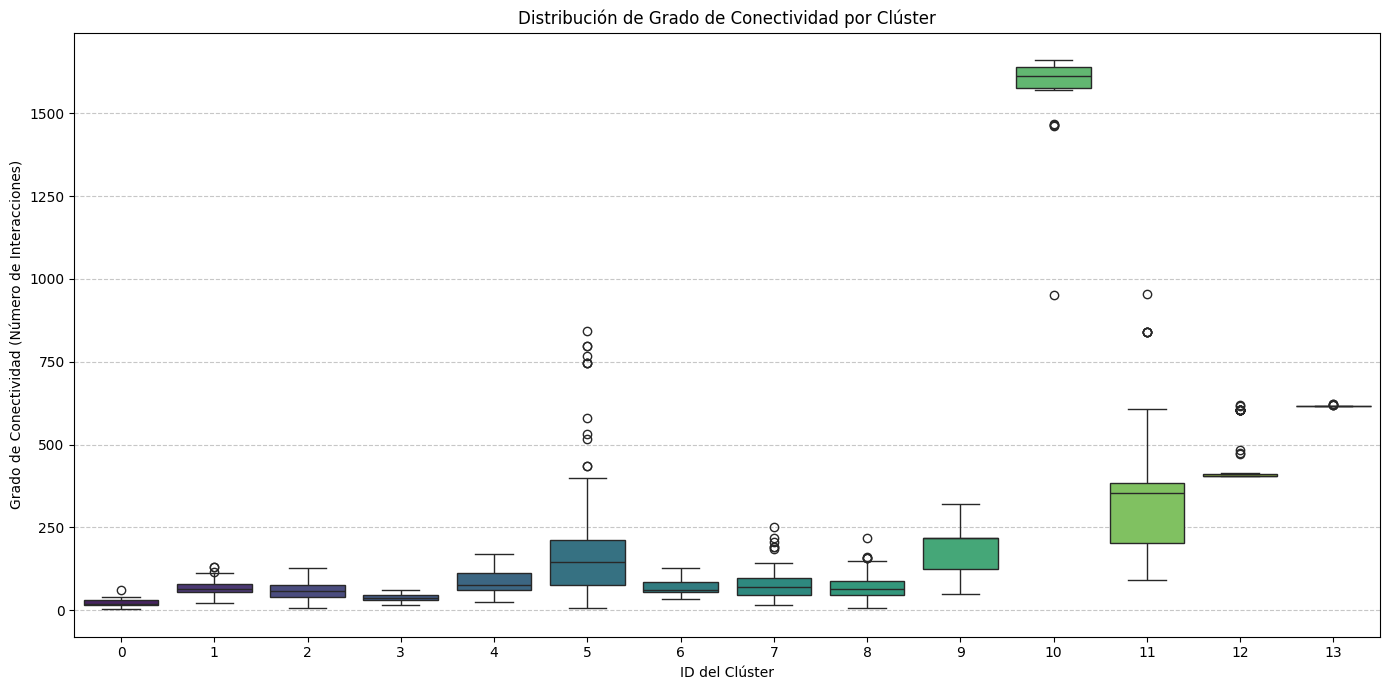

In [56]:
# Visualiza cómo se distribuye la conectividad de las proteínas dentro de cada clúster. Podrías ver que algunos clústeres tienen proteínas con grados mucho más altos que otros.
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_centrality_filtered, x='cluster_label', y='degree', palette='viridis')
plt.title('Distribución de Grado de Conectividad por Clúster')
plt.xlabel('ID del Clúster')
plt.ylabel('Grado de Conectividad (Número de Interacciones)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

    


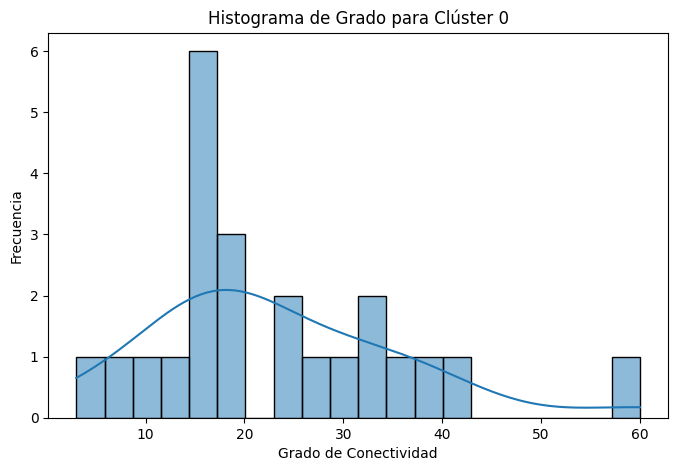

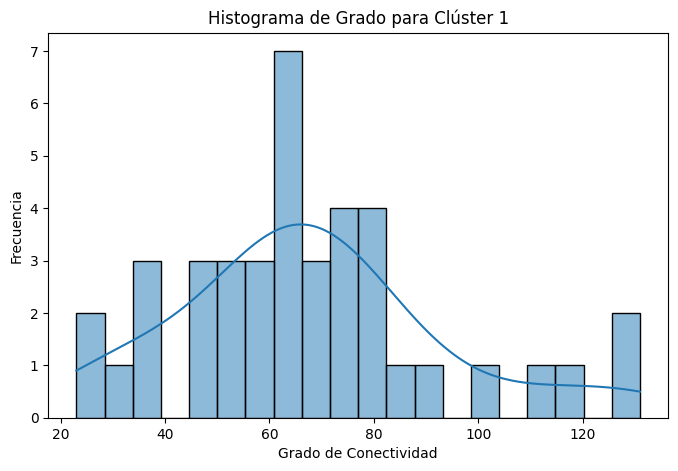

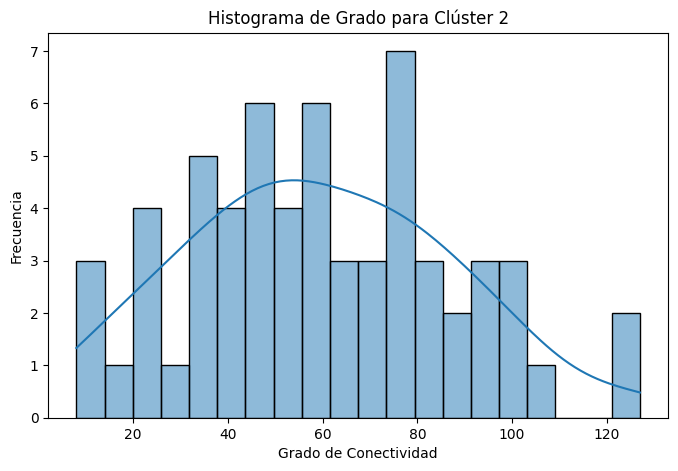

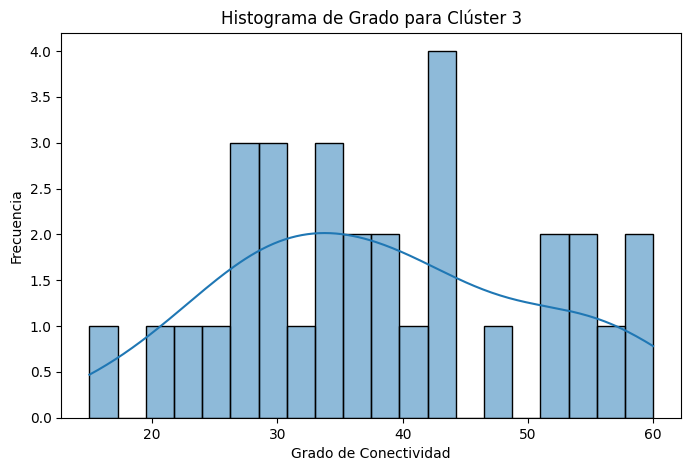

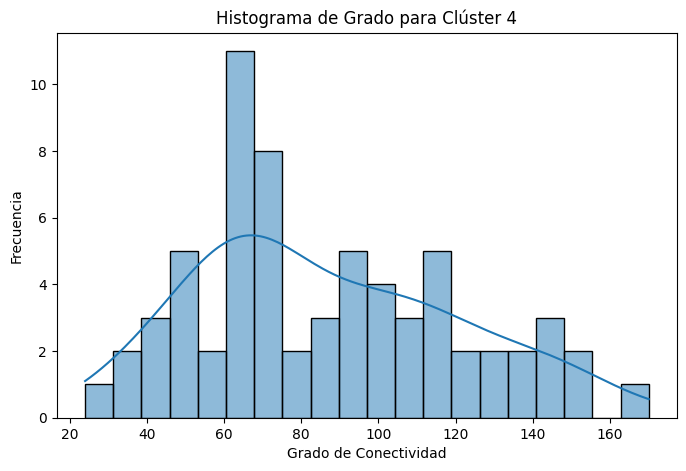

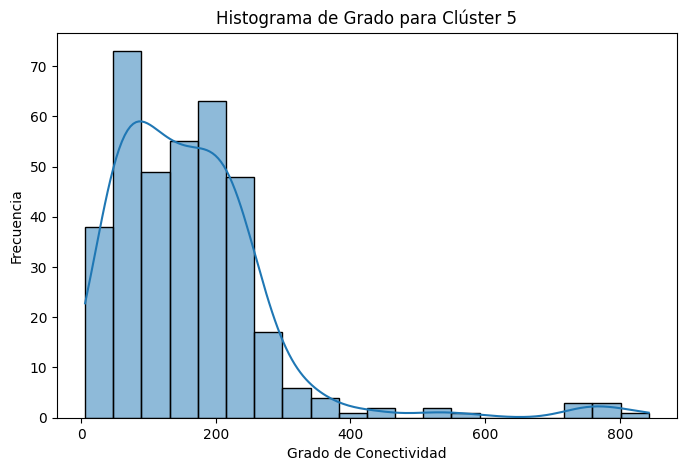

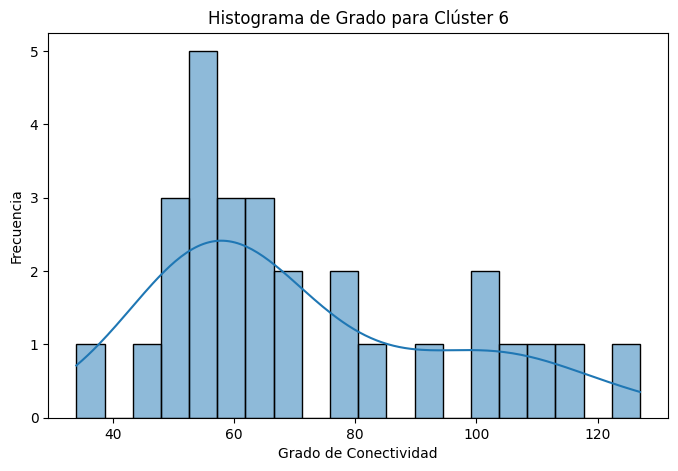

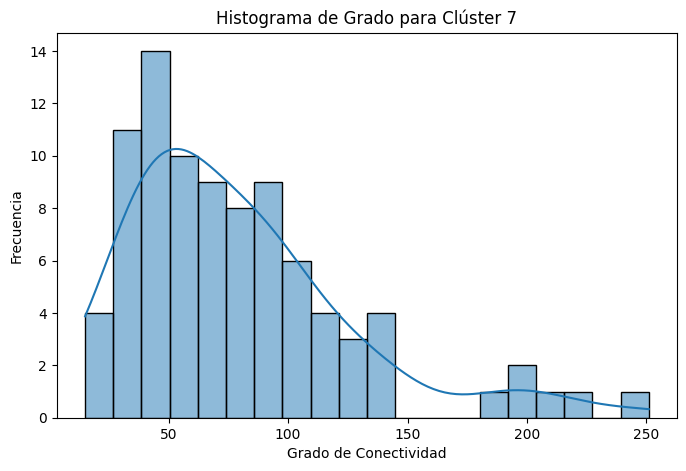

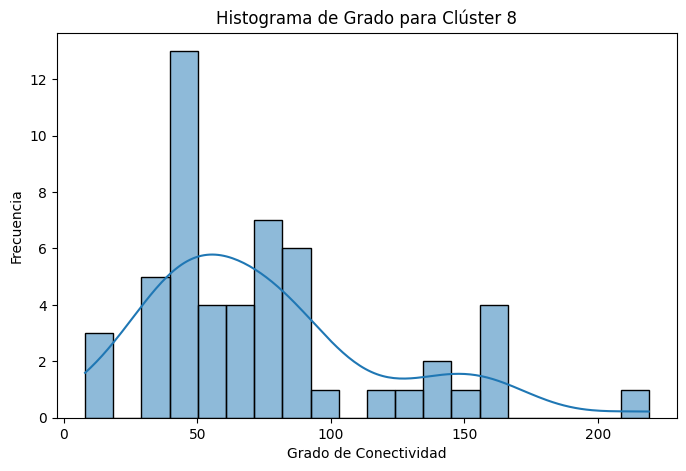

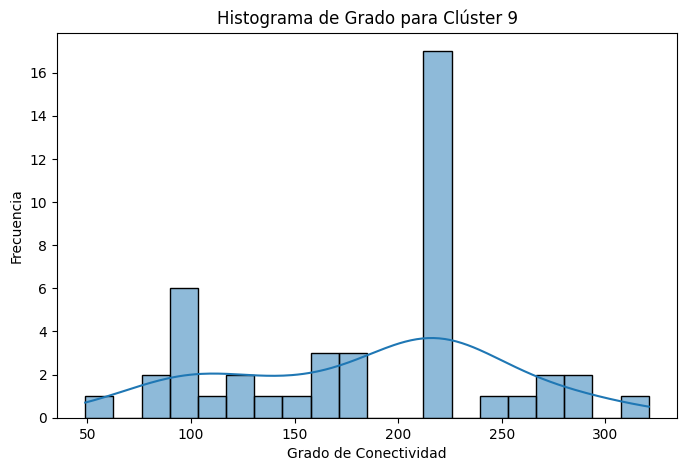

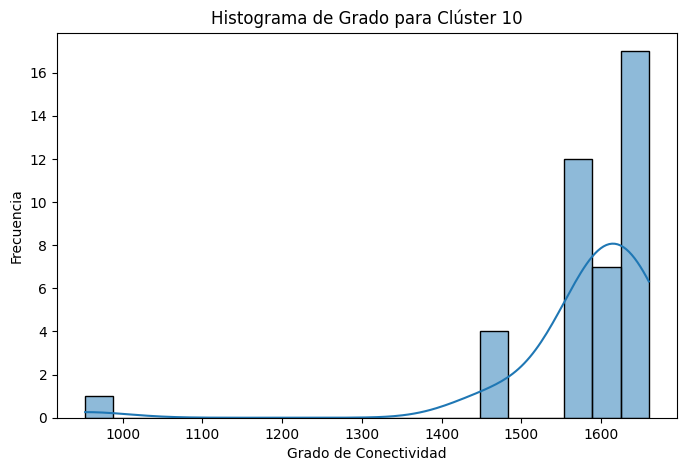

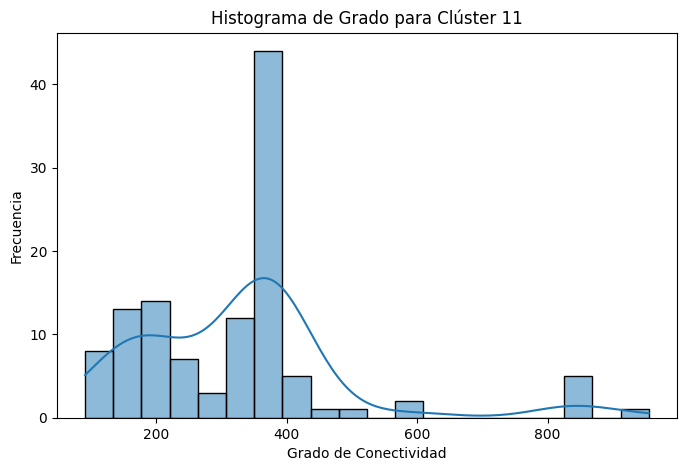

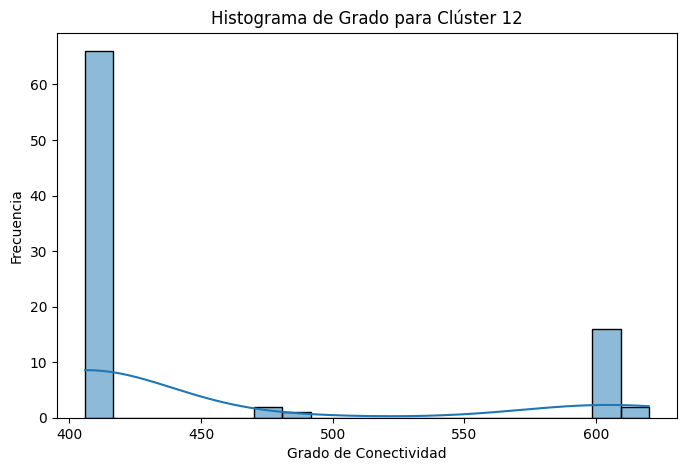

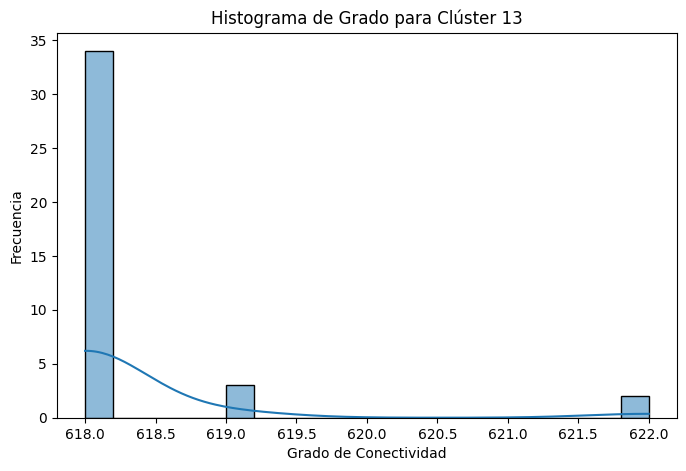

In [57]:
# Puedes hacer un histograma de los grados para cada clúster si el boxplot es muy denso
for cluster_id in valid_cluster_ids:
   plt.figure(figsize=(8, 5))
   cluster_df = df_centrality_filtered[df_centrality_filtered['cluster_label'] == cluster_id]
   if not cluster_df.empty:
    sns.histplot(cluster_df['degree'], bins=20, kde=True)
    plt.title(f'Histograma de Grado para Clúster {cluster_id}')
    plt.xlabel('Grado de Conectividad')
    plt.ylabel('Frecuencia')
    plt.show()

### 4.3. Heatmap de Centralidad por Clúster (Si se calcularon más métricas)


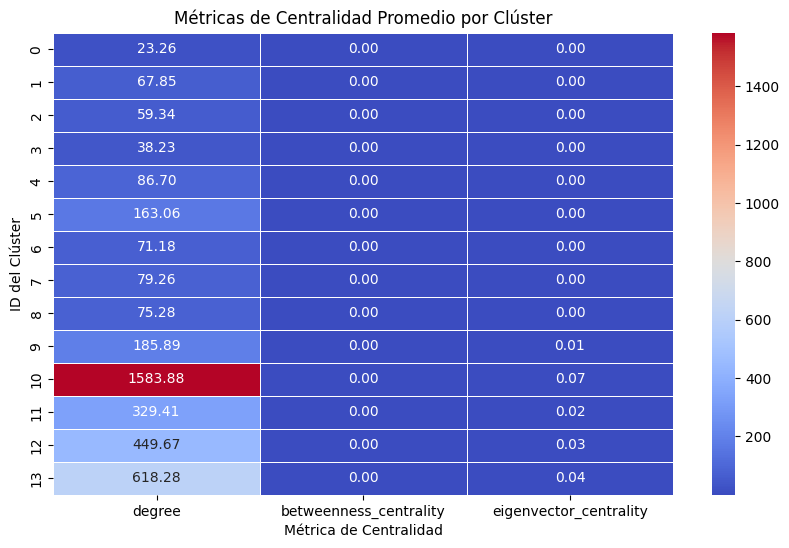

In [58]:
#Si calculaste `betweenness_centrality` y `eigenvector_centrality`, puedes hacer un heatmap que muestre el promedio de estas métricas por clúster.

if 'betweenness_centrality' in df_centrality_filtered.columns: # Comprueba si las métricas existen
    df_avg_centrality = df_centrality_filtered.groupby('cluster_label')[['degree', 'betweenness_centrality', 'eigenvector_centrality']].mean()
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_avg_centrality, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Métricas de Centralidad Promedio por Clúster')
    plt.xlabel('Métrica de Centralidad')
    plt.ylabel('ID del Clúster')
    plt.show()
else:
    print("Advertencia: No se calcularon métricas de betweenness o eigenvector centrality. Solo se mostró el grado.")

**Interpretación y significado para Alzheimer:**
* **Proteínas Hub en Clústeres Relevantes:** Si un clúster está enriquecido en funciones relacionadas con Alzheimer (ej., disfunción mitocondrial, señalización sináptica, metabolismo de esteroides) *y* contiene proteínas con muy alta conectividad, estas proteínas son candidatas principales como **moduladores clave o dianas terapéuticas**. Podrían ser puntos de control importantes en las vías afectadas por la enfermedad.
***Análisis del Grado:** Un box plot o histograma del grado te permitirá ver si algunos clústeres son inherentemente más "densos" o si contienen algunas proteínas "super-hub" mientras que el resto tiene baja conectividad.
